# SE4: Results Visualization

This notebook generates a reproducible figure package from the SE3 outputs. It reads the daily comparison table, the fit-metric table, and the coefficient table produced in SE3, then saves three digital figures to the `images/` folder:

1. Validation observed vs predicted daily outflow by plant  
2. Train vs validation skill summary by plant  
3. Plant-specific coefficient estimates with 95% HC3 robust confidence intervals




In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

BASE = Path(".")
IMAGES = BASE / "images"
DOCS = BASE / "docs"
IMAGES.mkdir(exist_ok=True)
DOCS.mkdir(exist_ok=True)


## Load SE3 outputs

Required files:
- `daily_comparison_long.csv`
- `fit_metrics.csv`
- `coefficients.csv`


In [4]:
long_df = pd.read_csv("SE3_all_in_one_outputs/model_data/evaluation/daily_comparison_long.csv", parse_dates=["Date"])
fit_metrics = pd.read_csv("SE3_all_in_one_outputs/model_data/statistical_model/fit_metrics.csv")
coefficients = pd.read_csv("SE3_all_in_one_outputs/model_data/statistical_model/coefficients.csv")

plants = list(long_df["plant"].drop_duplicates())
long_df.head()


,Date,plant,observed_daily_outflow,simulated_daily_outflow,doy,sin_doy,cos_doy
0,2015-01-02,Jylhämä,0.2268,0.118338,2,0.034398,0.999408
1,2015-01-03,Jylhämä,0.3924,0.368287,3,0.051584,0.998669
2,2015-01-04,Jylhämä,0.5328,0.449553,4,0.068755,0.997634
3,2015-01-05,Jylhämä,1.2456,1.318066,5,0.085906,0.996303
4,2015-01-06,Jylhämä,1.0872,1.222307,6,0.103031,0.994678


## Reconstruct validation predictions from the SE3 OLS specification

The figure package uses the same plant-specific formula as SE3:

`observed_daily_outflow ~ simulated_daily_outflow + sin_doy + cos_doy`

with a chronological 80/20 train–validation split and HC3 robust standard errors.


In [5]:
pred_rows = []

for plant in plants:
    df = long_df[long_df["plant"] == plant].sort_values("Date").copy()
    split_ix = int(len(df) * 0.8)
    train = df.iloc[:split_ix].copy()
    valid = df.iloc[split_ix:].copy()

    model = smf.ols(
        "observed_daily_outflow ~ simulated_daily_outflow + sin_doy + cos_doy",
        data=train
    ).fit(cov_type="HC3")

    train["predicted"] = model.predict(train)
    valid["predicted"] = model.predict(valid)

    train["split"] = "train"
    valid["split"] = "validation"

    pred_rows.append(train)
    pred_rows.append(valid)

predictions = pd.concat(pred_rows, ignore_index=True)
predictions.head()


,Date,plant,observed_daily_outflow,simulated_daily_outflow,doy,sin_doy,cos_doy,predicted,split
0,2015-01-02,Jylhämä,0.2268,0.118338,2,0.034398,0.999408,0.452906,train
1,2015-01-03,Jylhämä,0.3924,0.368287,3,0.051584,0.998669,0.632599,train
2,2015-01-04,Jylhämä,0.5328,0.449553,4,0.068755,0.997634,0.691369,train
3,2015-01-05,Jylhämä,1.2456,1.318066,5,0.085906,0.996303,1.314305,train
4,2015-01-06,Jylhämä,1.0872,1.222307,6,0.103031,0.994678,1.246143,train


In [13]:
print(coefficients.columns.tolist())

['plant', 'term', 'coefficient', 'std_error', 't_value', 'p_value', 'ci_lower', 'ci_upper', 'standardized_beta']


## Figure 1 — validation observed vs predicted daily outflow by plant

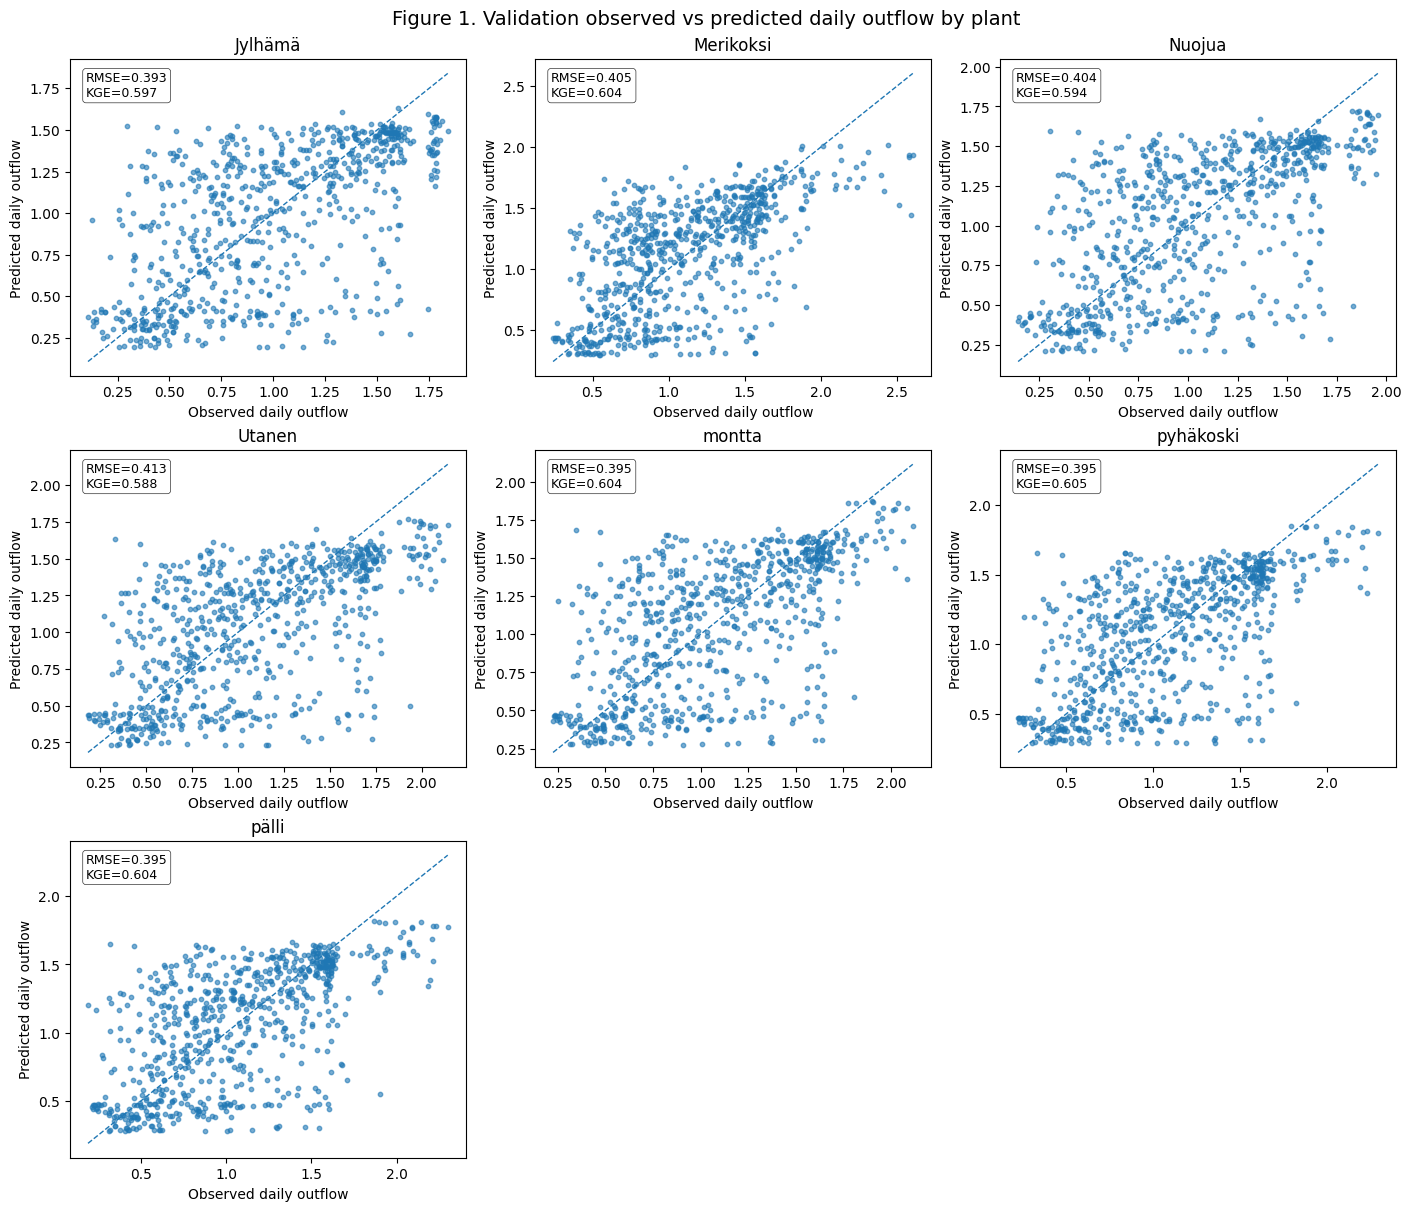

In [9]:
val = predictions[predictions["split"] == "validation"].copy()

cols = 3
rows = math.ceil(len(plants) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows), constrained_layout=True)
axes = axes.flatten()

for ax, plant in zip(axes, plants):
    d = val[val["plant"] == plant]
    ax.scatter(d["observed_daily_outflow"], d["predicted"], s=10, alpha=0.6)

    mn = min(d["observed_daily_outflow"].min(), d["predicted"].min())
    mx = max(d["observed_daily_outflow"].max(), d["predicted"].max())
    ax.plot([mn, mx], [mn, mx], linestyle="--", linewidth=1)

    m = fit_metrics[(fit_metrics["plant"] == plant) & (fit_metrics["split"] == "validation")].iloc[0]
    ax.text(
        0.04, 0.96,
        f"RMSE={m['RMSE']:.3f}\nKGE={m['KGE']:.3f}",
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, linewidth=0.5)
    )

    ax.set_title(plant)
    ax.set_xlabel("Observed daily outflow")
    ax.set_ylabel("Predicted daily outflow")

for ax in axes[len(plants):]:
    ax.axis("off")

fig.suptitle("Figure 1. Validation observed vs predicted daily outflow by plant", fontsize=14)
fig.savefig(IMAGES / "figure1_validation_scatter_by_plant.png", dpi=220, bbox_inches="tight")
plt.show()


## Figure 2 — train vs validation skill summary by plant

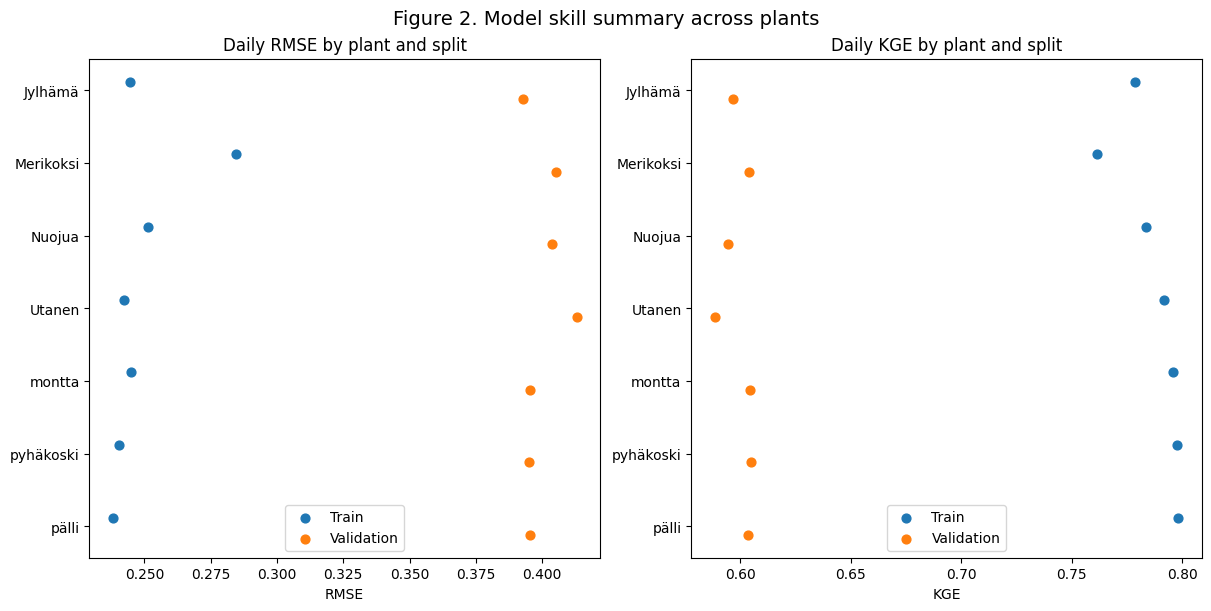

In [11]:
offset = {"train": -0.12, "validation": 0.12}

fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

for split in ["train", "validation"]:
    d = fit_metrics[fit_metrics["split"] == split].copy()
    d["plant_order"] = d["plant"].map({p: i for i, p in enumerate(plants)})
    d = d.sort_values("plant_order")

    y = np.arange(len(plants)) + offset[split]
    axes[0].scatter(d["RMSE"], y, label=split.capitalize(), s=40)
    axes[1].scatter(d["KGE"], y, label=split.capitalize(), s=40)

for ax in axes:
    ax.set_yticks(np.arange(len(plants)))
    ax.set_yticklabels(plants)
    ax.invert_yaxis()
    ax.legend()

axes[0].set_xlabel("RMSE")
axes[1].set_xlabel("KGE")
axes[0].set_title("Daily RMSE by plant and split")
axes[1].set_title("Daily KGE by plant and split")

fig.suptitle("Figure 2. Model skill summary across plants", fontsize=14)
fig.savefig(IMAGES / "figure2_skill_summary_by_plant.png", dpi=220, bbox_inches="tight")
plt.show()


## Figure 3 — coefficient estimates with 95% confidence intervals

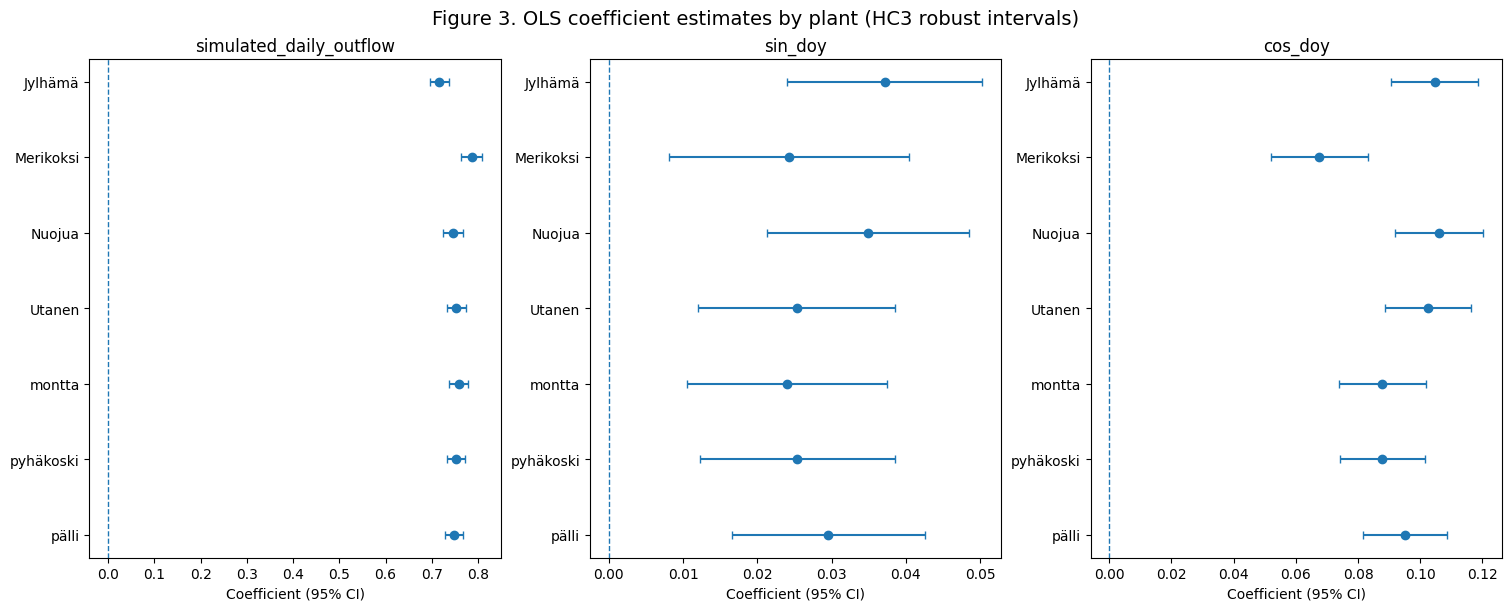

In [14]:
coef_plot = coefficients[coefficients["term"] != "Intercept"].copy()
term_order = ["simulated_daily_outflow", "sin_doy", "cos_doy"]

fig, axes = plt.subplots(1, 3, figsize=(15, 6), constrained_layout=True)

for ax, term in zip(axes, term_order):
    d = coef_plot[coef_plot["term"] == term].copy()
    d["plant_order"] = d["plant"].map({p: i for i, p in enumerate(plants)})
    d = d.sort_values("plant_order")

    y = np.arange(len(d))
    ax.errorbar(
        d["coefficient"], y,
        xerr=[d["coefficient"] - d["ci_lower"], d["ci_upper"] - d["coefficient"]],
        fmt="o", capsize=3
    )
    ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_title(term)
    ax.set_yticks(y)
    ax.set_yticklabels(d["plant"])
    ax.invert_yaxis()
    ax.set_xlabel("Coefficient (95% CI)")

fig.suptitle("Figure 3. OLS coefficient estimates by plant (HC3 robust intervals)", fontsize=14)
fig.savefig(IMAGES / "figure3_coefficients_by_plant.png", dpi=220, bbox_inches="tight")
plt.show()


## Figure captions

In [15]:
captions = {
    "Figure 1": 'Figure 1. Validation observed versus predicted daily outflow by plant. Points show daily validation observations from the final 20% of each plant time series. The dashed line is the 1:1 reference. Predictions come from plant-specific OLS models fit on the first 80% of the record using simulated daily outflow plus seasonal sine/cosine terms. Annotations report validation RMSE and KGE for each plant.',
    "Figure 2": 'Figure 2. Daily model skill summary across plants. Train and validation RMSE and KGE are shown for each plant. The gap between train and validation skill indicates the extent to which fitted performance generalizes to later periods rather than only the calibration period.',
    "Figure 3": 'Figure 3. Plant-specific OLS coefficient estimates with 95% HC3 robust confidence intervals. The simulated daily outflow term is consistently positive and larger in magnitude than the seasonal terms, indicating that modelled daily releases are the dominant predictor of observed daily outflow, while sin_doy and cos_doy capture residual seasonal structure.',
}
captions


{'Figure 1': 'Figure 1. Validation observed versus predicted daily outflow by plant. Points show daily validation observations from the final 20% of each plant time series. The dashed line is the 1:1 reference. Predictions come from plant-specific OLS models fit on the first 80% of the record using simulated daily outflow plus seasonal sine/cosine terms. Annotations report validation RMSE and KGE for each plant.',
 'Figure 2': 'Figure 2. Daily model skill summary across plants. Train and validation RMSE and KGE are shown for each plant. The gap between train and validation skill indicates the extent to which fitted performance generalizes to later periods rather than only the calibration period.',
 'Figure 3': 'Figure 3. Plant-specific OLS coefficient estimates with 95% HC3 robust confidence intervals. The simulated daily outflow term is consistently positive and larger in magnitude than the seasonal terms, indicating that modelled daily releases are the dominant predictor of observed 

## Replication notes

- Visualization functions: `matplotlib.pyplot.scatter`, `Axes.errorbar`, `Figure.savefig`
- Data input functions: `pandas.read_csv`
- Model reconstruction: `statsmodels.formula.api.ols(...).fit(cov_type="HC3")`
- Ancillary basemaps or GUI-only layers: none
- Post-hoc graphical editing outside Python: none


## Figure captions and methods/results update

In [18]:
(BASE / "captions_SE4.md").write_text(
    "# Figure captions\n\n"
    + "\n\n".join([f"## {k}\n{v}" for k, v in captions.items()]),
    encoding="utf-8"
)
print("Saved:", BASE / "captions_SE4.md")


Saved: captions_SE4.md
